<a href="https://colab.research.google.com/github/deba-biswas/seasonal-agriculture-analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis

**Major Project — Data Visualization**

This notebook analyzes the provided **Seasonal Agriculture Performance Dataset** to identify seasonal patterns, environmental relationships, resource-use efficiency, economic performance, crop differences, and regional variations.

### Objectives
- Clean and validate the agricultural dataset.
- Explore seasonal agricultural performance.
- Compare yield, production, revenue, cost, and profit.
- Study environmental factors such as rainfall, temperature, humidity, sunlight, and soil moisture.
- Analyze water usage, irrigation methods, fertilizer use, and water efficiency.
- Compare crop and state-level performance.
- Measure relationships using correlation analysis.
- Test whether seasonal differences in yield and profit are statistically significant.
- Build an optional Random Forest model using pre-harvest/environmental variables to estimate yield.
- Generate data-driven conclusions and recommendations.

> **Note:** All numerical findings are calculated from the supplied CSV file. The notebook does not hard-code project results.


## 1. Import Libraries

In [39]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, pearsonr
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

In [40]:
file_path = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_path)
print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Dataset loaded successfully.
Rows: 4,000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Dataset Structure and Data Types

In [41]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")
print("\nData types:")
display(df.dtypes.to_frame("Data Type"))


Dataset shape: (4000, 28)

Column names:
01. Farm_ID
02. State
03. District
04. Crop
05. Season
06. Farm_Area_Hectares
07. Rainfall_mm
08. Avg_Temperature_C
09. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


## 4. Descriptive Statistics

In [42]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 5. Missing Values

In [43]:
missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})
display(missing[missing["Missing Values"] > 0].sort_values("Missing Values", ascending=False))


,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


## 6. Duplicate Records

In [44]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")


Duplicate rows: 0
No duplicate rows found.


## 7. Data Cleaning

Numerical missing values are filled with the median because it is less sensitive to extreme observations than the mean. Categorical missing values, if any, are filled with the mode.


In [45]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])
print("Remaining missing values:", int(df.isna().sum().sum()))
print("Cleaned dataset shape:", df.shape)


Remaining missing values: 0
Cleaned dataset shape: (4000, 28)


## 8. Unique Categories

In [46]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())



Farm_ID:
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
SF13979    1
SF13978    1
SF13977    1
SF13976    1
SF13975    1
SF13974    1
SF13973    1
SF13972    1
SF13971    1
SF13970    1
SF13969    1
SF10032    1
SF10031    1
SF10030    1
SF10029    1
SF10028    1
SF10027    1
SF10026    1
SF10025    1
SF10024    1
SF10023    1
SF10022    1
SF10021    1
SF10020    1
SF10019    1
SF10018    1
SF10017    1
SF10048    1
SF10047    1
SF10046    1
SF10045    1
SF10044    1
SF10043    1
SF10042    1
SF10041    1
SF10040    1
SF10039    1
SF10038    1
SF10037    1
SF10036    1
SF10035    1
SF10034    1
SF10033    1
SF10064    1
SF10063    1
SF10062    1
SF10061    1
SF10060    1
SF10059    1
SF10058    1
SF10057    1
SF10056    1
SF10055    1
SF10054    1
SF10053    1
SF10052    1
SF10051    1
SF10050    1
SF10049    1
SF10080    1
SF10079    1
SF10078    1
SF10077    1
SF10076    1
SF10075    1
SF10074    1
SF10073    1
SF10072    1
SF10071    1
SF10070    1
SF10069

# Exploratory Data Analysis

## 9. Distribution of Farms by Season

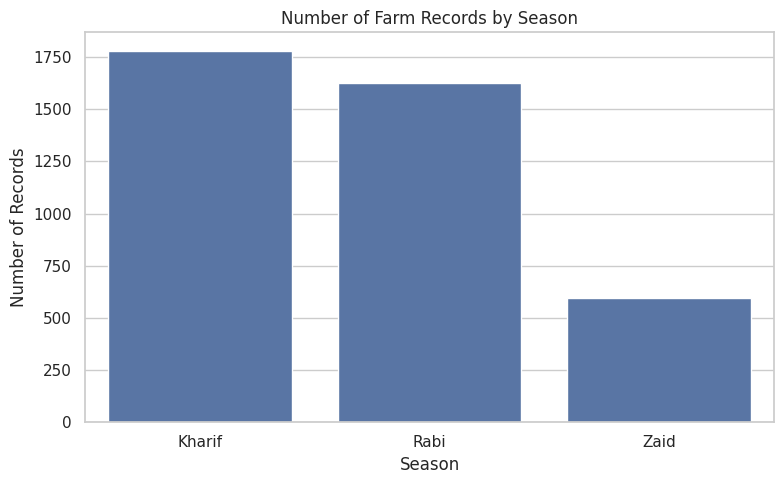

,Farm Records
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [47]:
season_counts = df["Season"].value_counts()
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Season", order=season_counts.index)
plt.title("Number of Farm Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()
display(season_counts.to_frame("Farm Records"))


## 10. Distribution of Crops

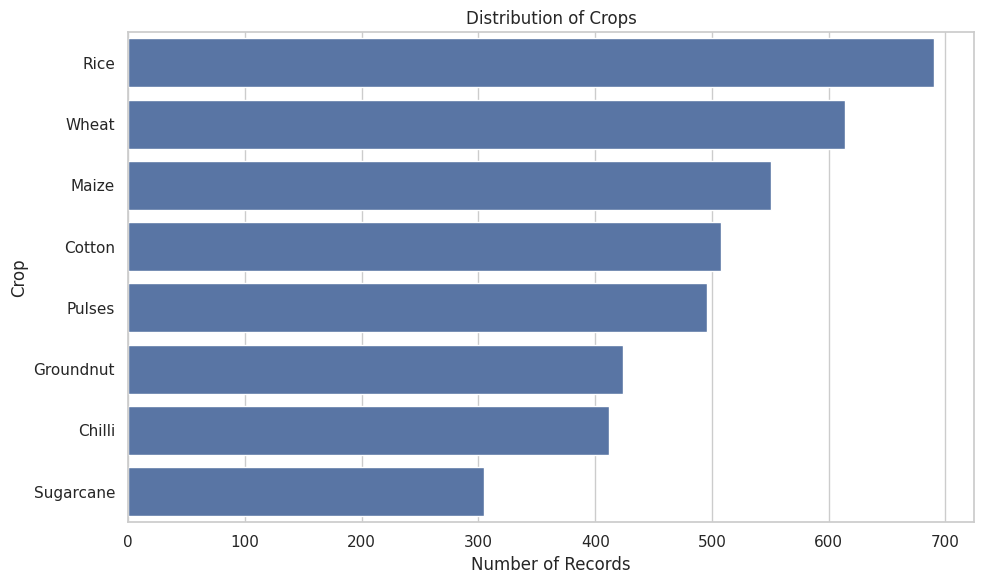

,Farm Records
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [48]:
crop_counts = df["Crop"].value_counts()
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="Crop", order=crop_counts.index)
plt.title("Distribution of Crops")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()
display(crop_counts.to_frame("Farm Records"))


## 11. State-wise Distribution

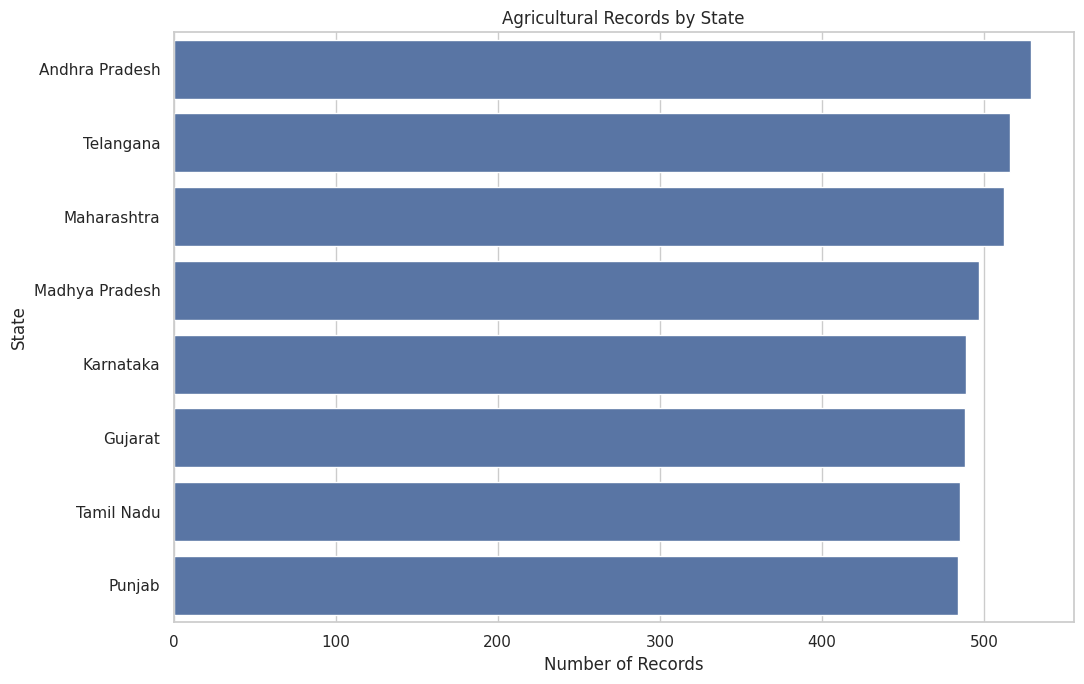

,Farm Records
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484


In [49]:
state_counts = df["State"].value_counts()
plt.figure(figsize=(11, 7))
sns.countplot(data=df, y="State", order=state_counts.index)
plt.title("Agricultural Records by State")
plt.xlabel("Number of Records")
plt.ylabel("State")
plt.tight_layout()
plt.show()
display(state_counts.to_frame("Farm Records"))


# Seasonal Performance Analysis

## 12. Seasonal Performance Summary

In [50]:
season_summary = df.groupby("Season").agg(
    Farm_Records=("Farm_ID", "count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_Tonnes=("Production_Tonnes", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Total_Cost_INR=("Total_Cost_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).round(2)
display(season_summary)


,Farm_Records,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Total_Cost_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk_pct
Season,,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,1627,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,594,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


## 13. Average Yield by Season

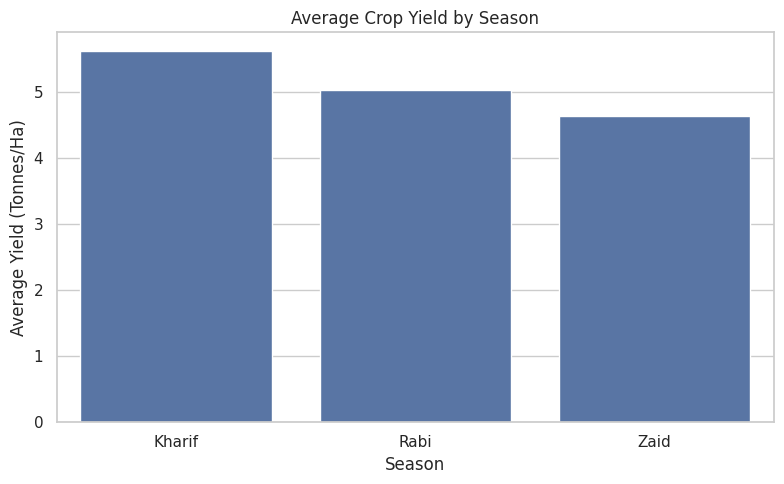

Highest average-yield season: Kharif
Lowest average-yield season: Zaid


In [51]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=season_yield.index, y=season_yield.values)
plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()
print("Highest average-yield season:", season_yield.idxmax())
print("Lowest average-yield season:", season_yield.idxmin())


## 14. Production by Season

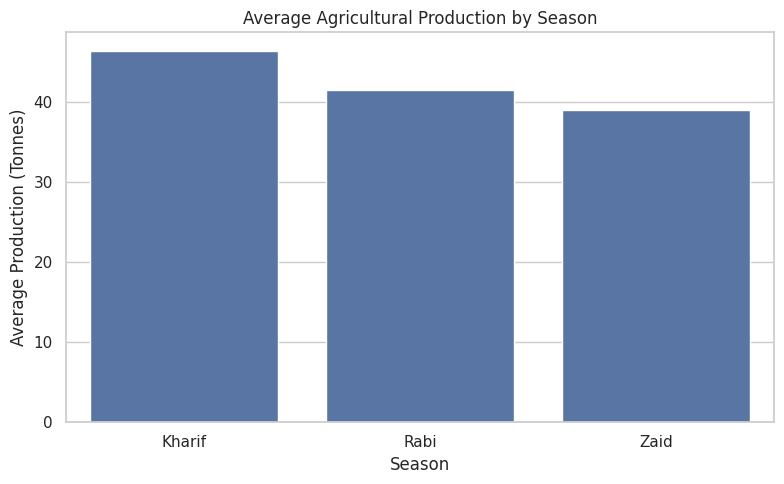

In [52]:
season_production = df.groupby("Season")["Production_Tonnes"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=season_production.index, y=season_production.values)
plt.title("Average Agricultural Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.tight_layout()
plt.show()


## 15. Revenue, Cost and Profit by Season

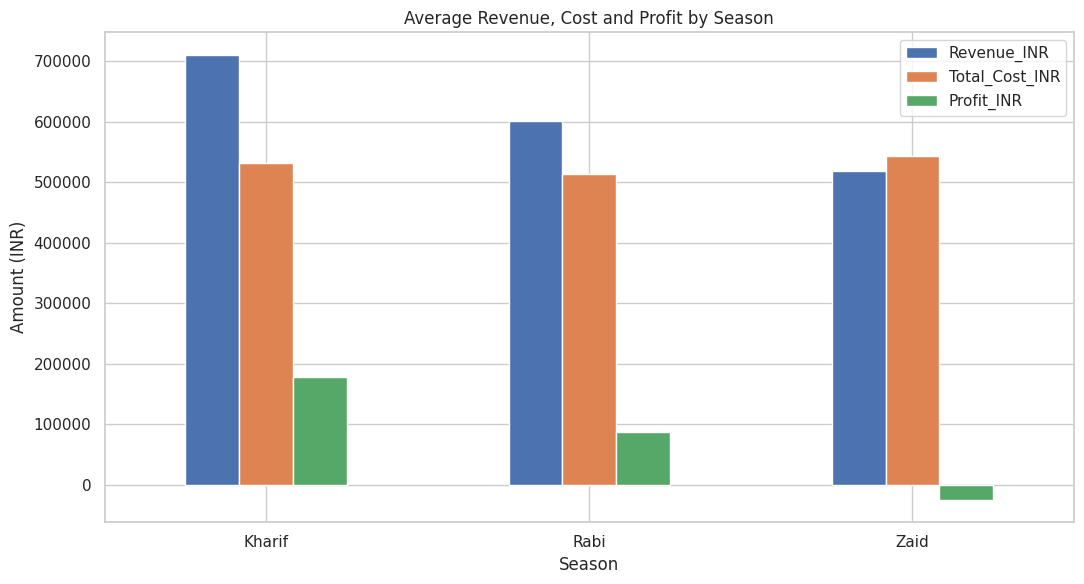

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82


In [53]:
economic_season = df.groupby("Season")[["Revenue_INR", "Total_Cost_INR", "Profit_INR"]].mean()
economic_season.plot(kind="bar", figsize=(11, 6))
plt.title("Average Revenue, Cost and Profit by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
display(economic_season.round(2))


## 16. Profit Margin by Season

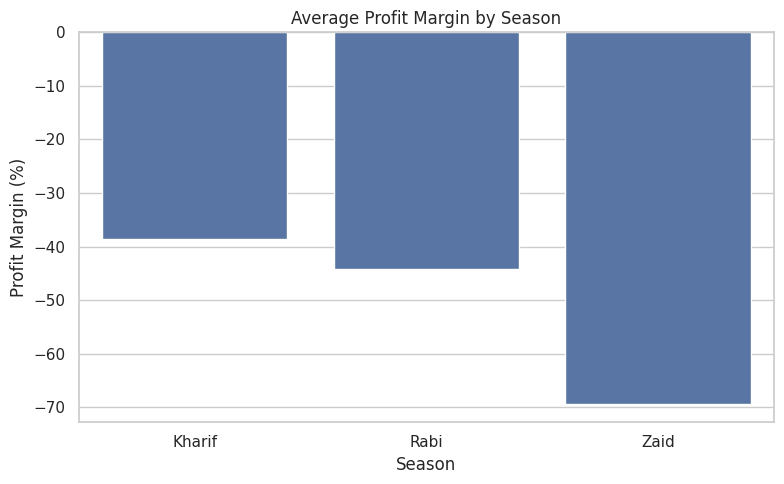

,Average Profit Margin (%)
Season,
Kharif,-38.64
Rabi,-44.27
Zaid,-69.35


In [54]:
df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    (df["Profit_INR"] / df["Revenue_INR"]) * 100,
    np.nan
)
profit_margin_season = df.groupby("Season")["Profit_Margin_pct"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=profit_margin_season.index, y=profit_margin_season.values)
plt.title("Average Profit Margin by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()
display(profit_margin_season.round(2).to_frame("Average Profit Margin (%)"))


# Environmental Analysis

## 17. Environmental Conditions Across Seasons

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


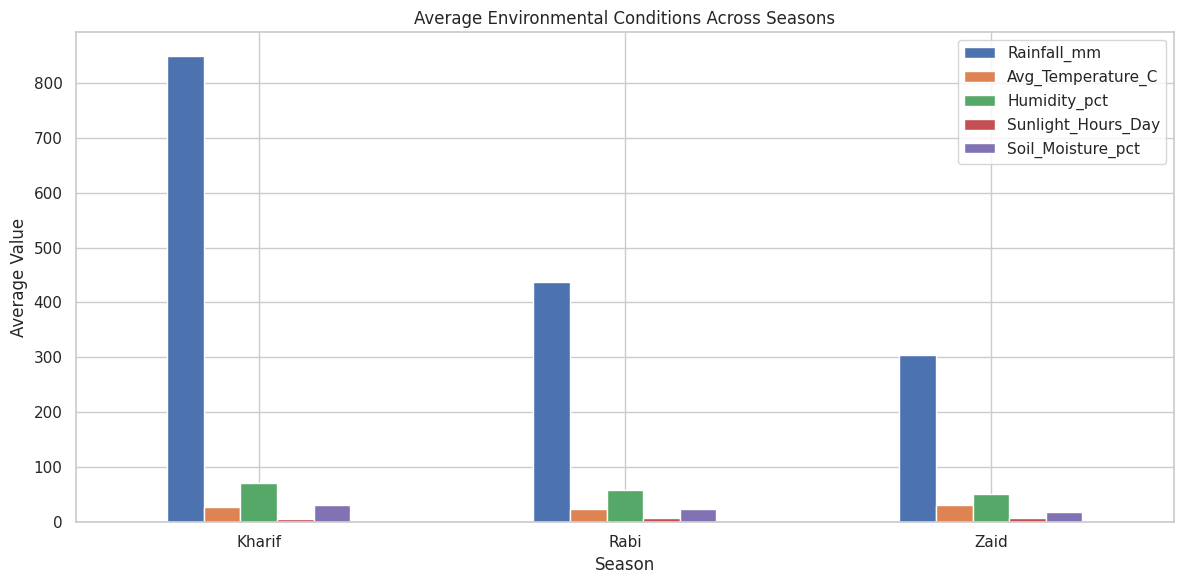

In [55]:
environmental_summary = df.groupby("Season").agg({
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Humidity_pct": "mean",
    "Sunlight_Hours_Day": "mean",
    "Soil_Moisture_pct": "mean"
}).round(2)
display(environmental_summary)
environmental_summary.plot(kind="bar", figsize=(12, 6))
plt.title("Average Environmental Conditions Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 18. Rainfall vs Yield

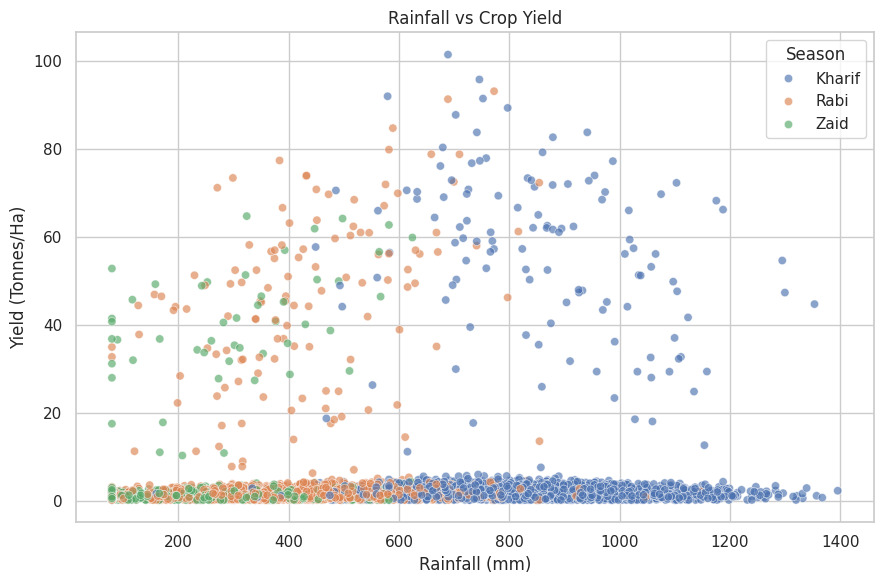

In [56]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.65)
plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


## 19. Temperature vs Yield

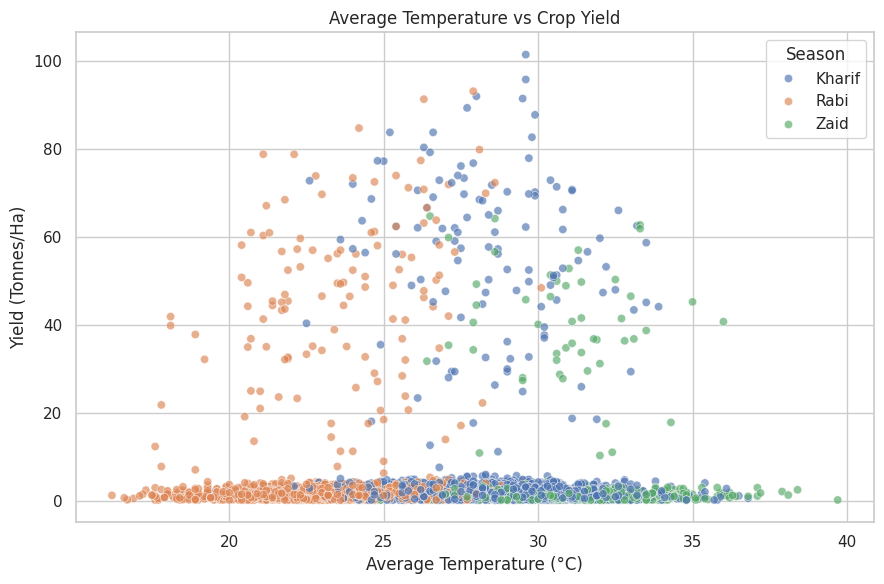

In [57]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Avg_Temperature_C", y="Yield_Tonnes_Ha", hue="Season", alpha=0.65)
plt.title("Average Temperature vs Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


## 20. Soil Moisture vs Yield

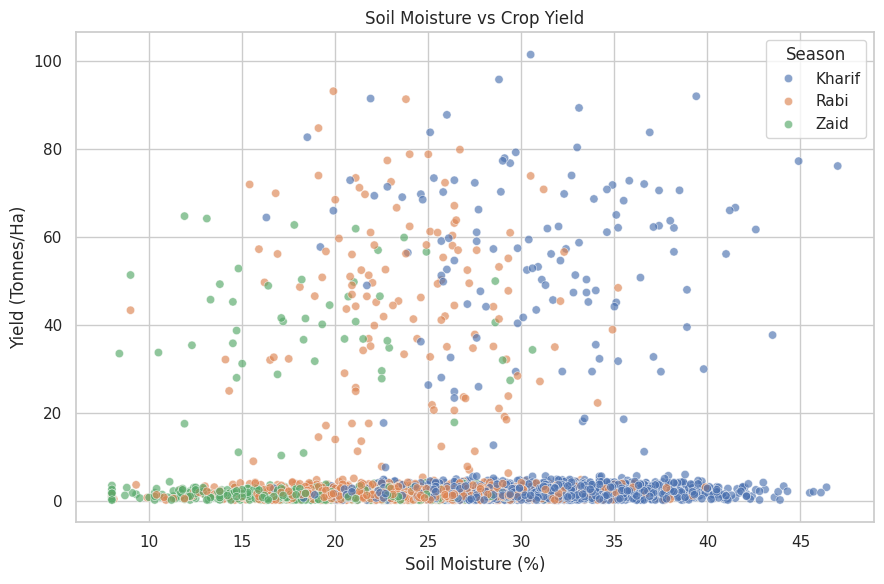

In [58]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Soil_Moisture_pct", y="Yield_Tonnes_Ha", hue="Season", alpha=0.65)
plt.title("Soil Moisture vs Crop Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


# Resource Utilization

## 21. Water Usage and Water Efficiency by Season

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,
Kharif,6102.20,5.89,187.08,5.08
Rabi,5846.99,5.19,185.41,5.02
Zaid,6419.89,4.41,184.64,5.17


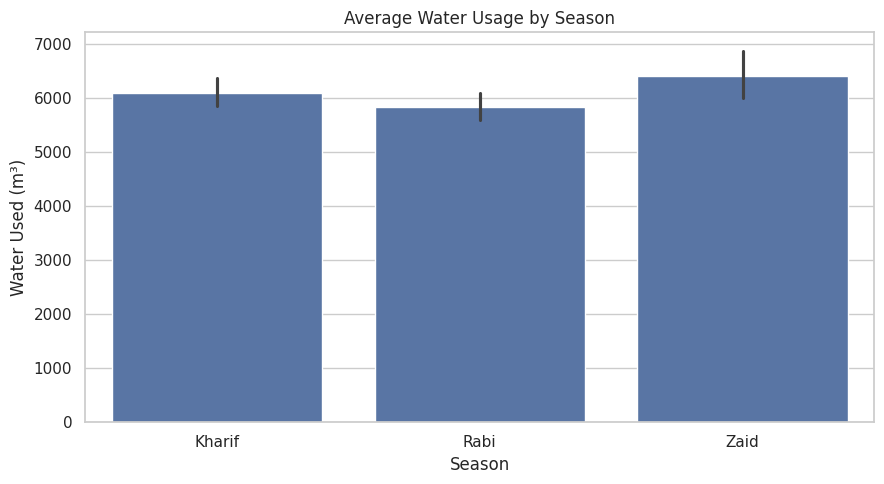

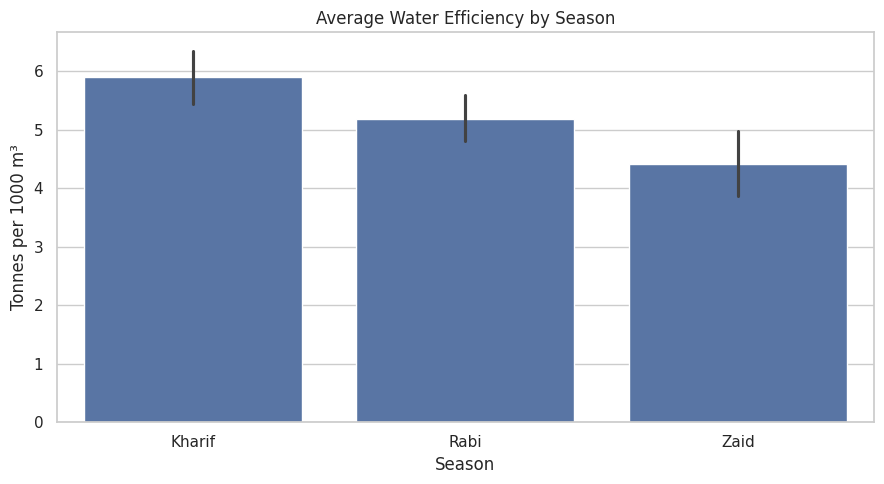

In [59]:
resource_summary = df.groupby("Season").agg({
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Fertilizer_kg_ha": "mean",
    "Pesticide_Litre_ha": "mean"
}).round(2)
display(resource_summary)
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Season", y="Water_Efficiency_t_per_1000m3")
plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.tight_layout()
plt.show()


## 22. Irrigation Method Analysis

,Avg_Yield,Avg_Water_Used,Avg_Water_Efficiency,Avg_Profit
Irrigation_Method,,,,
Rainfed,4.60,3549.55,7.56,79050.37
Drip,6.58,5918.75,6.27,219626.00
Sprinkler,5.16,6208.26,4.67,91121.08
Flood,4.86,8026.47,3.44,73354.02


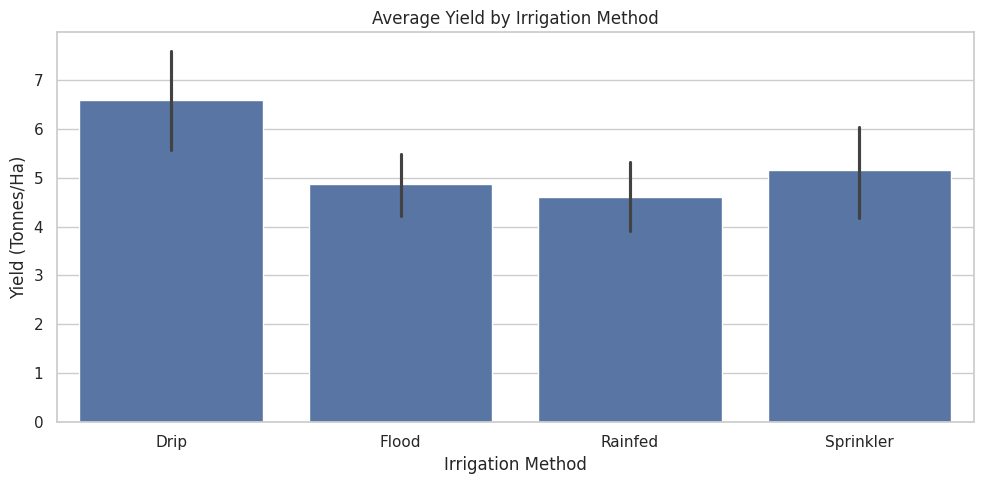

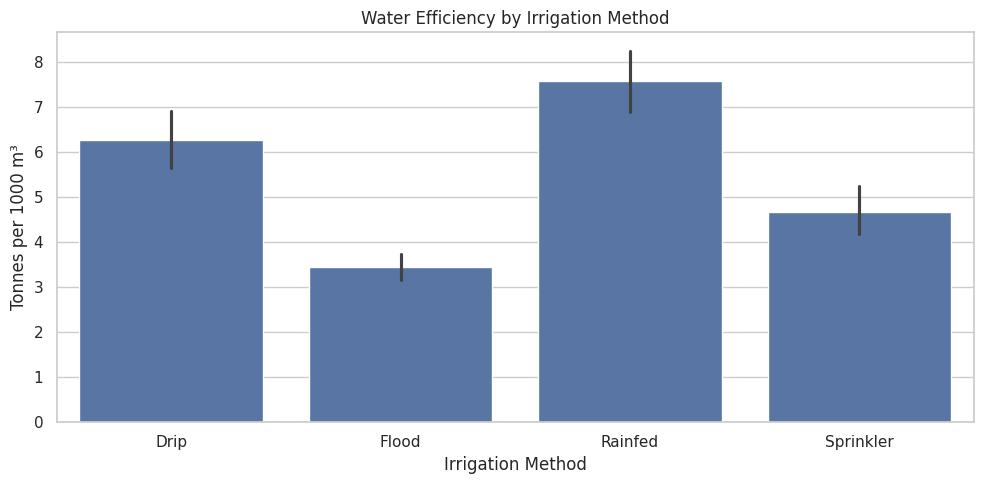

In [60]:
irrigation_summary = df.groupby("Irrigation_Method").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).sort_values("Avg_Water_Efficiency", ascending=False).round(2)
display(irrigation_summary)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha")
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Water_Efficiency_t_per_1000m3")
plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Tonnes per 1000 m³")
plt.tight_layout()
plt.show()


# Crop Analysis

## 23. Crop-wise Yield and Profit

,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Profit,Avg_Water_Efficiency
Crop,,,,,
Sugarcane,46.64,392.41,1371980.11,817187.99,30.48
Maize,2.71,21.78,457067.99,-83978.33,5.60
Rice,2.43,19.29,423615.26,-102213.50,1.95
Wheat,2.11,16.85,400104.89,-123398.34,4.63
Chilli,1.54,12.38,1276777.23,750878.34,2.95
Groundnut,1.32,9.66,542935.50,44858.12,3.15
Cotton,1.23,9.40,639423.08,124546.92,1.94
Pulses,0.92,7.40,528465.87,-4238.05,2.90


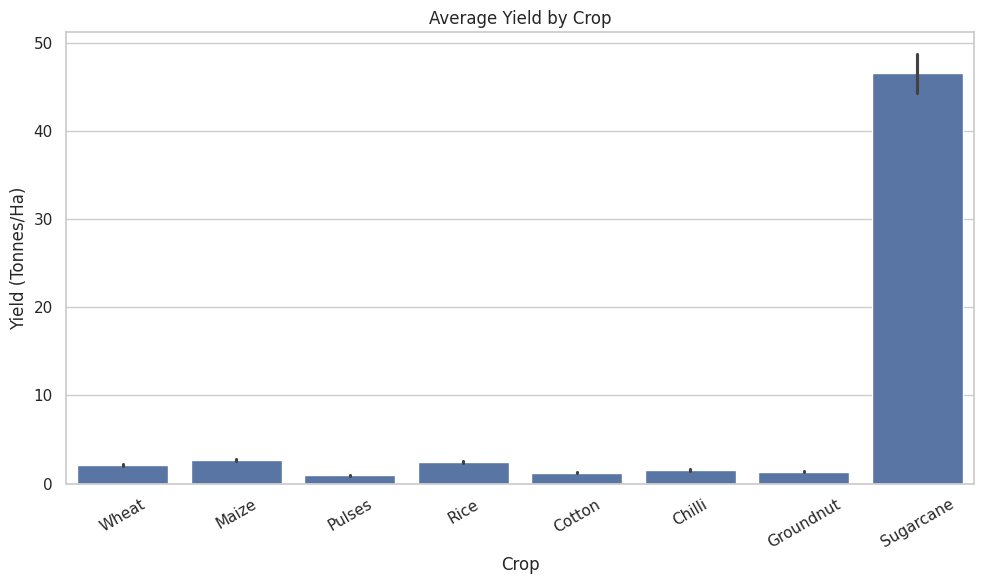

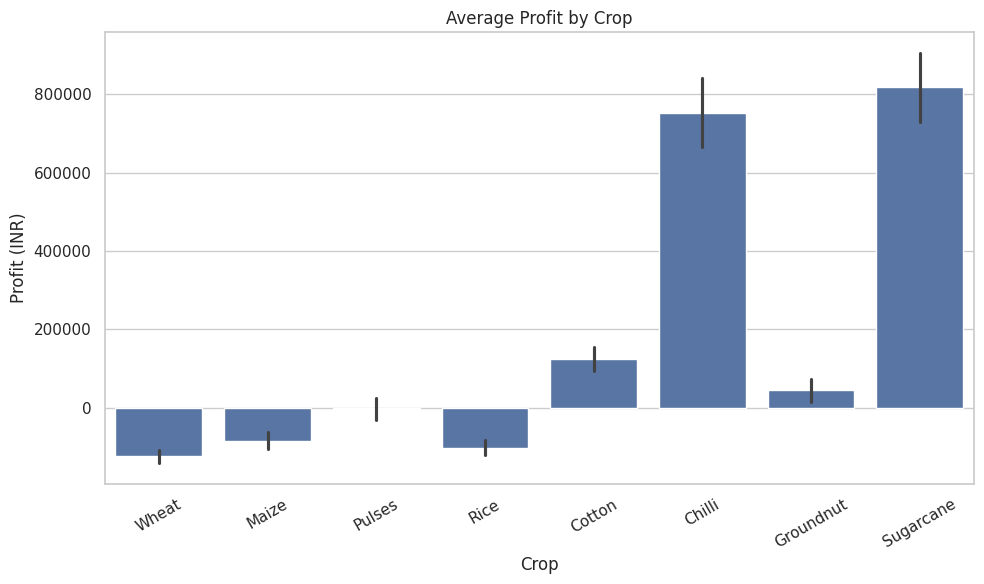

In [61]:
crop_summary = df.groupby("Crop").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Yield", ascending=False).round(2)
display(crop_summary)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Crop", y="Yield_Tonnes_Ha")
plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Crop", y="Profit_INR")
plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Profit (INR)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 24. Crop Performance Across Seasons

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


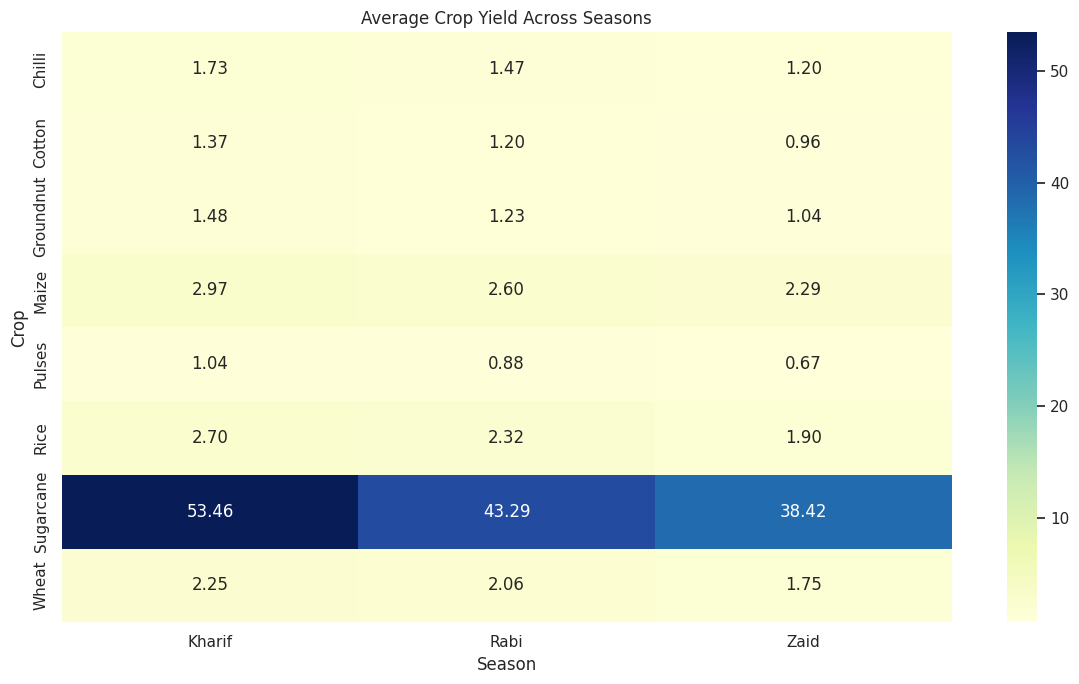

In [62]:
crop_season_yield = pd.pivot_table(df, values="Yield_Tonnes_Ha", index="Crop", columns="Season", aggfunc="mean")
display(crop_season_yield.round(2))
plt.figure(figsize=(12, 7))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


# Regional Analysis

## 25. State-wise Agricultural Performance

,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Profit,Avg_Water_Efficiency
State,,,,,
Punjab,6.12,52.23,686225.70,136025.64,5.62
Karnataka,5.69,47.73,653426.18,119422.34,5.56
Gujarat,5.66,48.33,654692.86,117568.24,5.58
Telangana,5.04,39.25,628784.53,108829.62,5.46
Maharashtra,5.02,43.98,650032.67,135428.86,5.28
Madhya Pradesh,4.99,37.56,597558.36,86840.76,5.27
Tamil Nadu,4.88,40.84,629093.42,117744.75,5.31
Andhra Pradesh,4.63,36.91,606663.66,73453.53,5.03


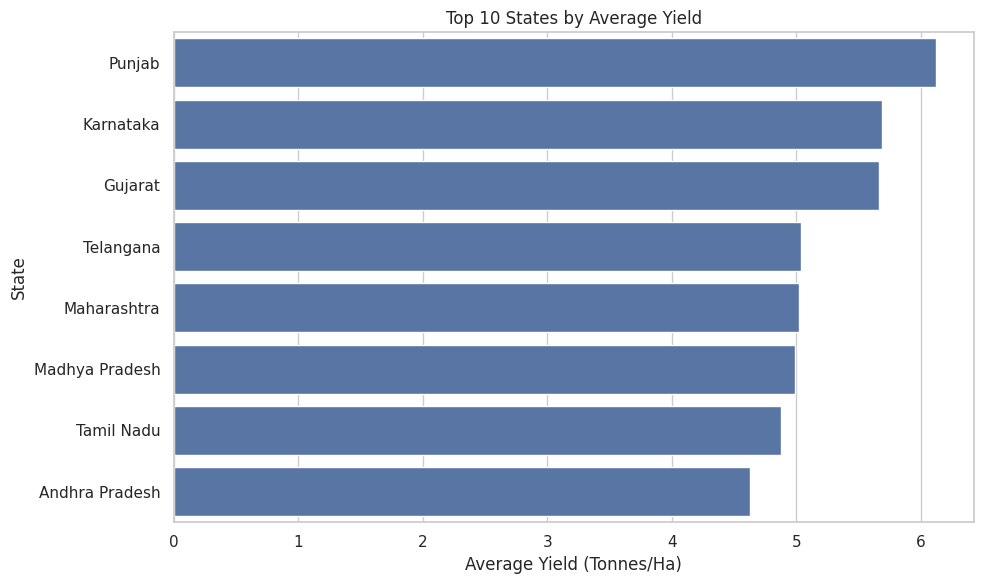

In [63]:
state_performance = df.groupby("State").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Yield", ascending=False).round(2)
display(state_performance)
top_states = state_performance.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_states["Avg_Yield"], y=top_states.index)
plt.title("Top 10 States by Average Yield")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


# Correlation Analysis

## 26. Correlation Matrix

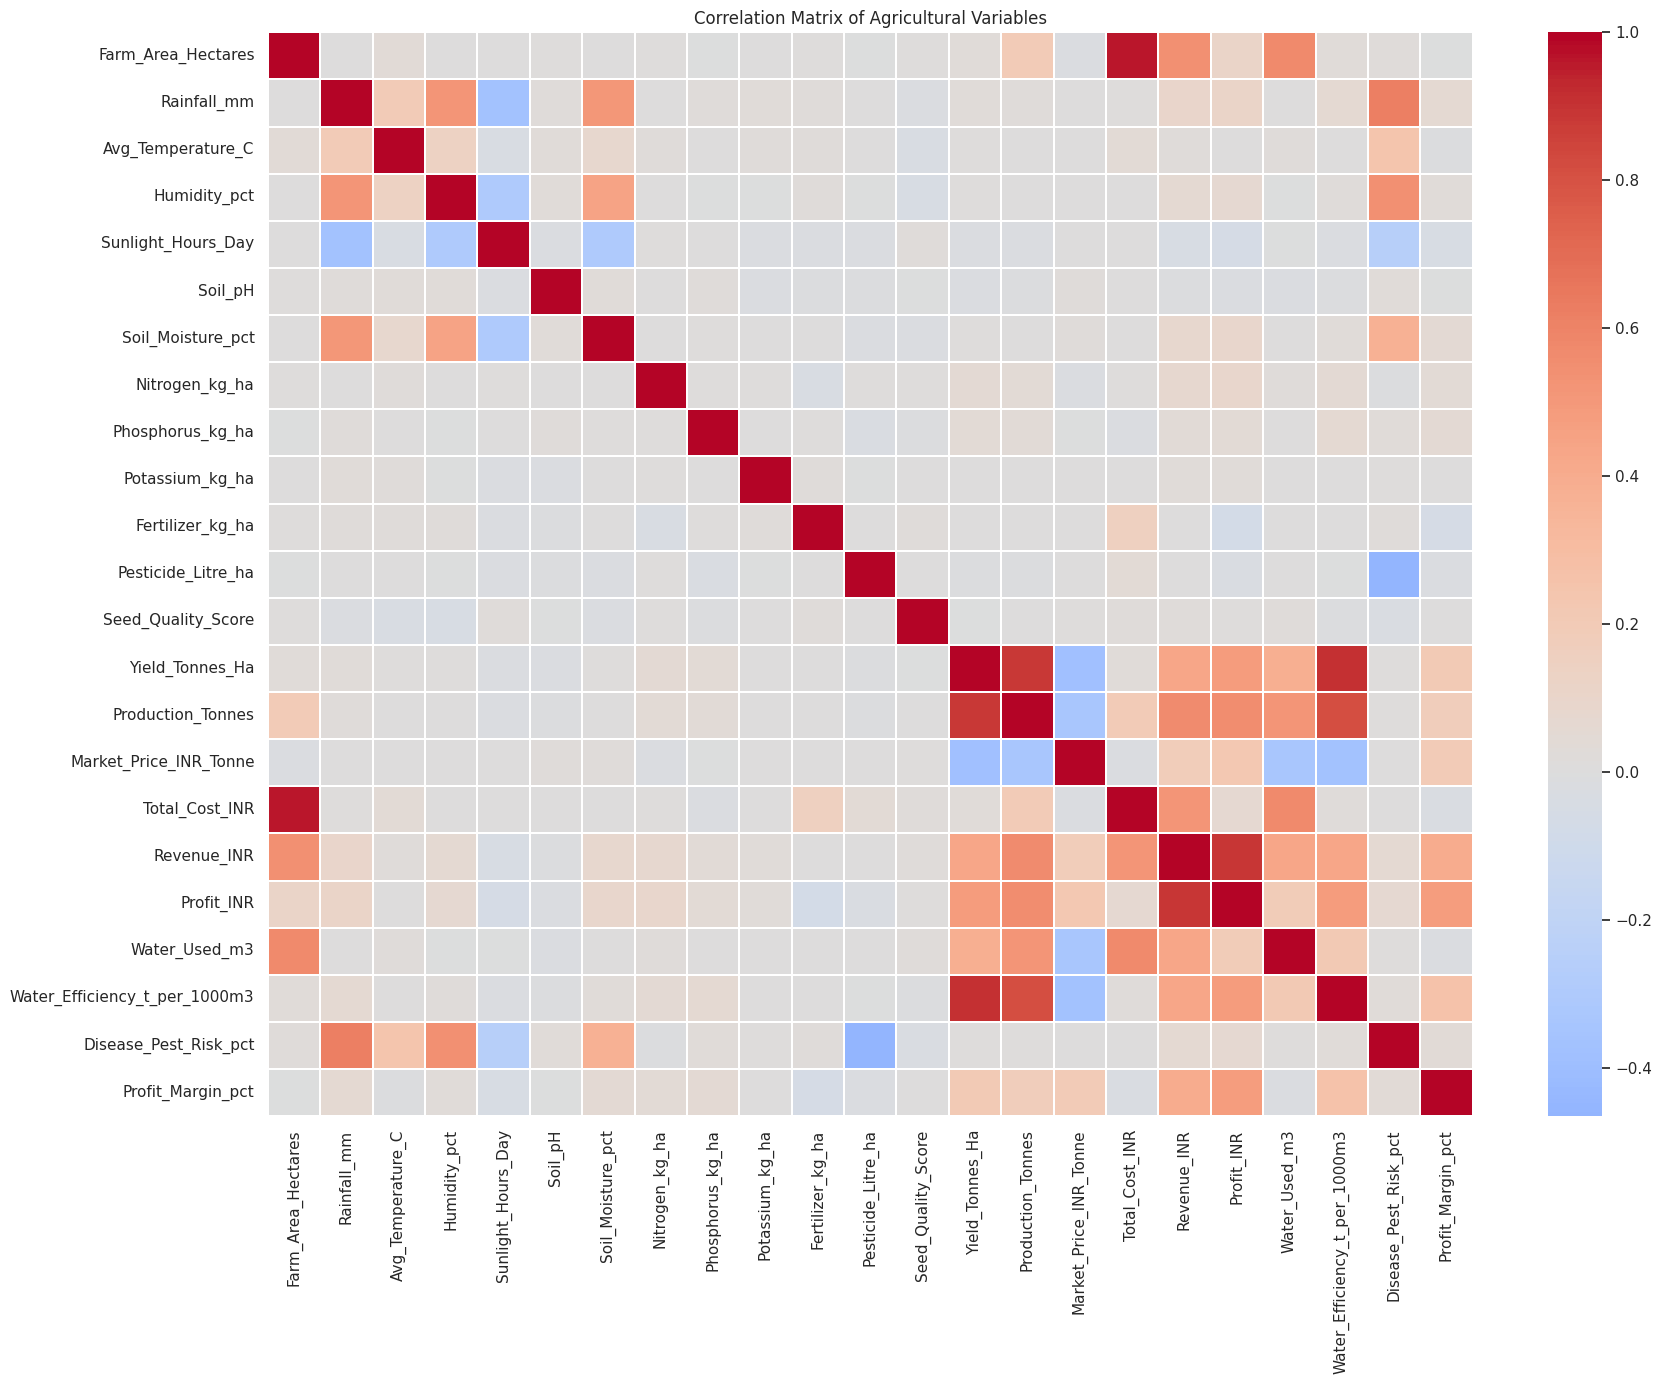

In [64]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Matrix of Agricultural Variables")
plt.tight_layout()
plt.show()


## 27. Variables Most Related to Yield

In [65]:
yield_correlation = correlation_matrix["Yield_Tonnes_Ha"].sort_values(ascending=False)
display(yield_correlation.to_frame("Correlation with Yield"))


,Correlation with Yield
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Profit_Margin_pct,0.204993
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951


## 28. Pearson Correlation Tests for Selected Factors

Correlation shows association, not causation. These tests quantify the strength and direction of selected linear relationships.


In [66]:
selected_factors = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
    "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Seed_Quality_Score", "Water_Used_m3", "Disease_Pest_Risk_pct"
]
corr_results = []
for col in selected_factors:
    r, p = pearsonr(df[col], df["Yield_Tonnes_Ha"])
    corr_results.append({"Variable": col, "Pearson_r": r, "p_value": p, "Significant_at_5pct": p < 0.05})
corr_results = pd.DataFrame(corr_results).sort_values("Pearson_r", key=lambda s: s.abs(), ascending=False)
display(corr_results.round(4))


,Variable,Pearson_r,p_value,Significant_at_5pct
10,Water_Used_m3,0.3863,0.0000,True
5,Nitrogen_kg_ha,0.0531,0.0008,True
6,Phosphorus_kg_ha,0.0479,0.0024,True
0,Rainfall_mm,0.0310,0.0503,False
3,Sunlight_Hours_Day,-0.0153,0.3320,False
11,Disease_Pest_Risk_pct,0.0143,0.3662,False
2,Humidity_pct,0.0123,0.4368,False
4,Soil_Moisture_pct,0.0110,0.4868,False
1,Avg_Temperature_C,0.0100,0.5274,False
9,Seed_Quality_Score,-0.0072,0.6486,False


# Statistical Testing

## 29. One-Way ANOVA: Does Season Affect Yield?

**Null hypothesis (H₀):** Mean yield is equal across seasons.

**Alternative hypothesis (H₁):** At least one season has a different mean yield.

A p-value below 0.05 is treated as statistically significant.


In [67]:
season_groups = [group["Yield_Tonnes_Ha"].values for _, group in df.groupby("Season")]
anova_yield_stat, anova_yield_p = f_oneway(*season_groups)
print(f"F-statistic: {anova_yield_stat:.4f}")
print(f"p-value: {anova_yield_p:.6f}")
if anova_yield_p < 0.05:
    print("Conclusion: Seasonal differences in mean yield are statistically significant at the 5% level.")
else:
    print("Conclusion: No statistically significant seasonal difference in mean yield was detected at the 5% level.")


F-statistic: 1.5439
p-value: 0.213678
Conclusion: No statistically significant seasonal difference in mean yield was detected at the 5% level.


## 30. One-Way ANOVA: Does Season Affect Profit?

**Null hypothesis (H₀):** Mean profit is equal across seasons.

**Alternative hypothesis (H₁):** At least one season has a different mean profit.


In [68]:
profit_groups = [group["Profit_INR"].values for _, group in df.groupby("Season")]
anova_profit_stat, anova_profit_p = f_oneway(*profit_groups)
print(f"F-statistic: {anova_profit_stat:.4f}")
print(f"p-value: {anova_profit_p:.6f}")
if anova_profit_p < 0.05:
    print("Conclusion: Seasonal differences in mean profit are statistically significant at the 5% level.")
else:
    print("Conclusion: No statistically significant seasonal difference in mean profit was detected at the 5% level.")


F-statistic: 34.2918
p-value: 0.000000
Conclusion: Seasonal differences in mean profit are statistically significant at the 5% level.


# Economic Risk Analysis

## 31. Profitable vs Loss-Making Farms

Loss-making farm records: 1,966 (49.15%)


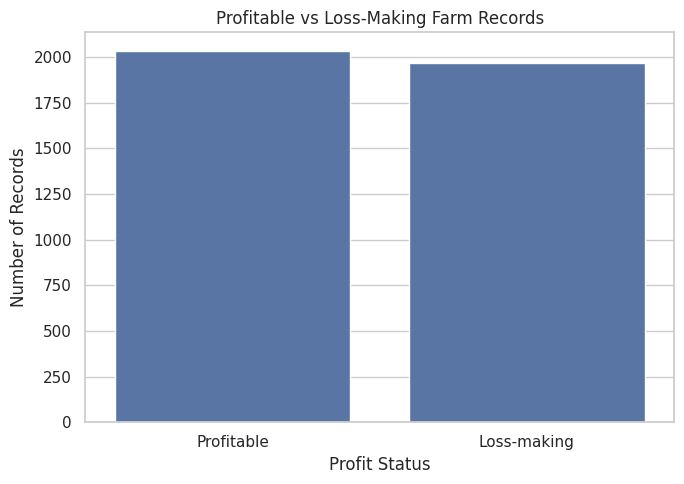

In [69]:
profit_status = np.where(df["Profit_INR"] >= 0, "Profitable", "Loss-making")
status_counts = pd.Series(profit_status).value_counts()
loss_count = int((df["Profit_INR"] < 0).sum())
loss_percentage = loss_count / len(df) * 100
print(f"Loss-making farm records: {loss_count:,} ({loss_percentage:.2f}%)")
plt.figure(figsize=(7, 5))
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title("Profitable vs Loss-Making Farm Records")
plt.xlabel("Profit Status")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


## 32. Highest and Lowest Performing Groups

In [70]:
best_yield_season = season_summary["Avg_Yield_Tonnes_Ha"].idxmax()
worst_yield_season = season_summary["Avg_Yield_Tonnes_Ha"].idxmin()
best_profit_season = season_summary["Avg_Profit_INR"].idxmax()
worst_profit_season = season_summary["Avg_Profit_INR"].idxmin()
best_water_season = season_summary["Avg_Water_Efficiency"].idxmax()
best_crop_yield = crop_summary["Avg_Yield"].idxmax()
best_crop_profit = crop_summary["Avg_Profit"].idxmax()
best_irrigation_yield = irrigation_summary["Avg_Yield"].idxmax()
best_irrigation_water = irrigation_summary["Avg_Water_Efficiency"].idxmax()
print("Best season by yield:", best_yield_season)
print("Lowest season by yield:", worst_yield_season)
print("Best season by profit:", best_profit_season)
print("Lowest season by profit:", worst_profit_season)
print("Best season by water efficiency:", best_water_season)
print("Highest-yielding crop:", best_crop_yield)
print("Highest-profit crop:", best_crop_profit)
print("Best irrigation method by yield:", best_irrigation_yield)
print("Best irrigation method by water efficiency:", best_irrigation_water)


Best season by yield: Kharif
Lowest season by yield: Zaid
Best season by profit: Kharif
Lowest season by profit: Zaid
Best season by water efficiency: Kharif
Highest-yielding crop: Sugarcane
Highest-profit crop: Sugarcane
Best irrigation method by yield: Drip
Best irrigation method by water efficiency: Rainfed


# Optional Predictive Extension

## 33. Random Forest Yield Prediction

This extension estimates yield using variables available before or during cultivation. Downstream outcome variables such as production, revenue, profit, and water-efficiency ratios are excluded to reduce target leakage.


In [71]:
target = "Yield_Tonnes_Ha"
feature_cols = [
    "State", "District", "Crop", "Season", "Farm_Area_Hectares", "Rainfall_mm",
    "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day", "Soil_pH",
    "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Irrigation_Method", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Disease_Pest_Risk_pct"
]
X = df[feature_cols]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()
preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numeric", "passthrough", numeric_features)
])
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error: 0.7616
R² Score: 0.9630


## 34. Actual vs Predicted Yield

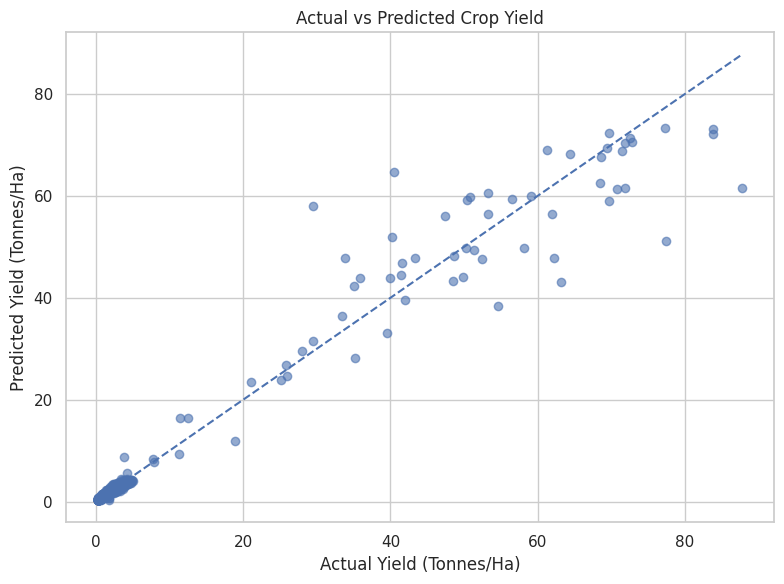

In [72]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title("Actual vs Predicted Crop Yield")
plt.xlabel("Actual Yield (Tonnes/Ha)")
plt.ylabel("Predicted Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


## 35. Feature Importance

,Feature,Importance
24,categorical__Crop_Sugarcane,0.798215
38,numeric__Soil_pH,0.136052
34,numeric__Rainfall_mm,0.024216
40,numeric__Nitrogen_kg_ha,0.006428
42,numeric__Potassium_kg_ha,0.004267
35,numeric__Avg_Temperature_C,0.003675
44,numeric__Pesticide_Litre_ha,0.002595
43,numeric__Fertilizer_kg_ha,0.002540
45,numeric__Seed_Quality_Score,0.002256
33,numeric__Farm_Area_Hectares,0.002181


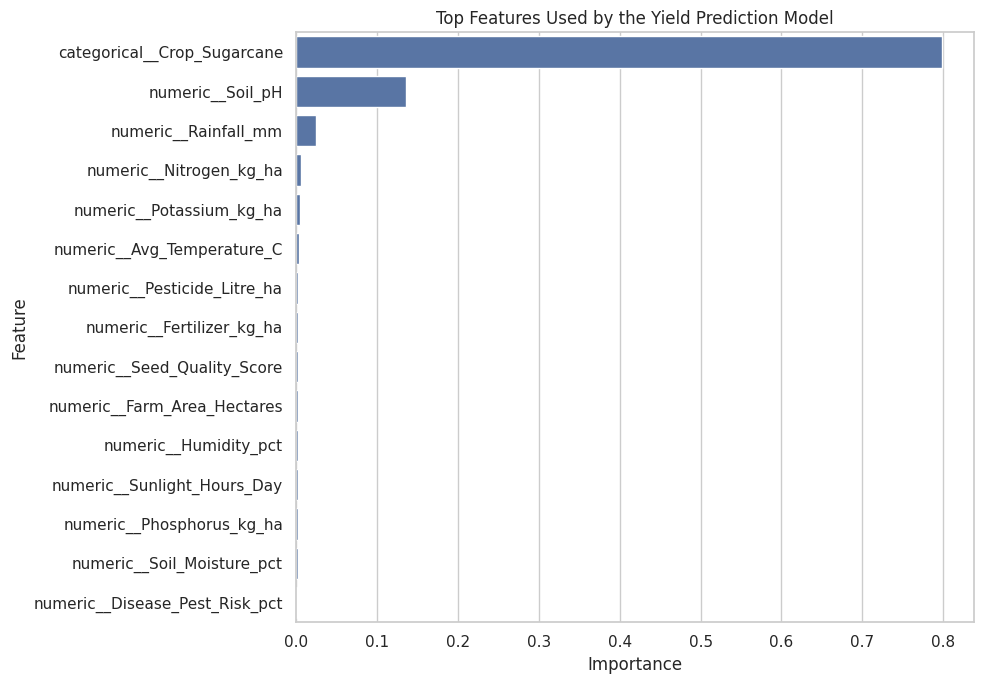

In [73]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_
feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values("Importance", ascending=False)
display(feature_importance.head(20))
top_features = feature_importance.head(15)
plt.figure(figsize=(10, 7))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top Features Used by the Yield Prediction Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Final Findings and Recommendations

## 36. Key Finding

In [74]:
print("=" * 70)
print("SEASONAL AGRICULTURE PERFORMANCE — KEY FINDINGS")
print("=" * 70)
print("Dataset size:", f"{len(df):,}", "records")
print("Seasons:", df["Season"].nunique(), "| Crops:", df["Crop"].nunique(), "| States:", df["State"].nunique())
print("\nBest season by yield:", best_yield_season, f"({season_summary.loc[best_yield_season, 'Avg_Yield_Tonnes_Ha']:.2f} tonnes/ha)")
print("Best season by profit:", best_profit_season, f"(₹{season_summary.loc[best_profit_season, 'Avg_Profit_INR']:,.2f})")
print("Most water-efficient season:", best_water_season, f"({season_summary.loc[best_water_season, 'Avg_Water_Efficiency']:.2f} tonnes/1000 m³)")
print("Highest-yielding crop:", best_crop_yield, f"({crop_summary.loc[best_crop_yield, 'Avg_Yield']:.2f} tonnes/ha)")
print("Highest-profit crop:", best_crop_profit, f"(₹{crop_summary.loc[best_crop_profit, 'Avg_Profit']:,.2f})")
print("Best irrigation method by yield:", best_irrigation_yield)
print("Best irrigation method by water efficiency:", best_irrigation_water)
print("Loss-making records:", f"{loss_count:,} ({loss_percentage:.2f}%)")
print("Yield ANOVA p-value:", f"{anova_yield_p:.6f}")
print("Profit ANOVA p-value:", f"{anova_profit_p:.6f}")
print("Random Forest R²:", f"{r2:.4f}")


SEASONAL AGRICULTURE PERFORMANCE — KEY FINDINGS
Dataset size: 4,000 records
Seasons: 3 | Crops: 8 | States: 8

Best season by yield: Kharif (5.63 tonnes/ha)
Best season by profit: Kharif (₹178,914.65)
Most water-efficient season: Kharif (5.89 tonnes/1000 m³)
Highest-yielding crop: Sugarcane (46.64 tonnes/ha)
Highest-profit crop: Sugarcane (₹817,187.99)
Best irrigation method by yield: Drip
Best irrigation method by water efficiency: Rainfed
Loss-making records: 1,966 (49.15%)
Yield ANOVA p-value: 0.213678
Profit ANOVA p-value: 0.000000
Random Forest R²: 0.9630


## 37. Recommendations

1. **Seasonal planning:** Prioritize crop and resource planning around seasons showing stronger yield and/or profitability in the dataset.
2. **Crop-season matching:** Use the crop-by-season yield matrix to identify combinations associated with stronger productivity.
3. **Water management:** Compare irrigation methods using both yield and water-efficiency metrics rather than water consumption alone.
4. **Environmental monitoring:** Monitor rainfall, temperature, humidity, and soil moisture because these variables show measurable relationships with agricultural outcomes.
5. **Cost control:** Examine high-cost and loss-making records to identify opportunities for improving profitability.
6. **Regional planning:** Use state-level performance comparisons to identify regions requiring additional resource planning or investigation.
7. **Predictive analytics:** The Random Forest extension can be developed further with larger, higher-quality, and time-series datasets for yield forecasting.

> **Important:** Correlation shows the relationship between variables, but it does not prove causation.


# 38. Export Results

In [75]:
df.to_csv("cleaned_seasonal_agriculture_dataset.csv", index=False)
season_summary.to_csv("seasonal_performance_summary.csv")
crop_summary.to_csv("crop_performance_summary.csv")
state_performance.to_csv("state_performance_summary.csv")
irrigation_summary.to_csv("irrigation_performance_summary.csv")
corr_results.to_csv("yield_correlation_tests.csv", index=False)
feature_importance.to_csv("yield_model_feature_importance.csv", index=False)
print("Export completed successfully.")


Export completed successfully.


# 39. Final Project Summary

### Project
**Seasonal Agriculture Performance Analysis**

### Main analytical areas
- Data cleaning and validation
- Exploratory data analysis
- Seasonal performance comparison
- Environmental factor analysis
- Resource and water-efficiency analysis
- Crop and irrigation comparison
- Regional analysis
- Correlation analysis
- ANOVA statistical testing
- Optional Random Forest yield prediction

### Final takeaway
The analysis provides a structured, data-driven view of how agricultural productivity, resource efficiency, and economic outcomes vary across seasons and farming conditions.
